In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeManilaV2
from qiskit.visualization import plot_histogram

import qiskit.quantum_info as qi
import numpy as np
import time

ImportError: cannot import name 'MCZGate' from 'qiskit.circuit.library' (c:\Users\iraja\config\python\python312\Lib\site-packages\qiskit\circuit\library\__init__.py)

In [94]:
def oracle(iter, n, states):
  qc = QuantumCircuit(n)
  for state in states:
    # Inverter onde é 0 para 1: motivo simular a porta CZ
    for i, bit in enumerate(reversed(state)):
      if bit == '0':
        qc.x(i)
    
    # Simular a porta CZ múltipla para inverter a fase (marcar os estados com a fase)
    qc.h(n - 1)
    qc.mcx(list(range(n - 1)), n - 1)
    qc.h(n - 1)

    # Reverte os X para manter o estado original
    for i, bit in enumerate(reversed(state)):
      if bit == '0':
        qc.x(i)
  return qc.to_instruction(label=f'Oracle')

def diffuser(iter, n):
  qc = QuantumCircuit(n)
  # Colocar todos em H e X
  qc.h(range(n))
  qc.x(range(n))
  # Simular a multi-controlada Z
  qc.h(n-1)
  qc.mcx(list(range(n-1)), n-1)
  qc.h(n-1)
  # Desfazer X e H
  qc.x(range(n))
  qc.h(range(n))
  return qc.to_instruction(label=f'Diffusion')

def create_grover_circuit(marked):
  n = len(marked[0]) 
  iterations = int(np.floor(np.pi / 4 * np.sqrt(2 ** n / len(marked))))

  qc = QuantumCircuit(n, n)
  qc.h(range(n)) 
  qc.barrier()

  for i in range(iterations):
    qc.append(oracle(i + 1, n, marked), list(range(n)))
    qc.barrier()
    qc.append(diffuser(i + 1, n), list(range(n)))
    qc.barrier()

  qc.measure(list(range(n)), list(range(n)))
  return qc, iterations

def execute(qc, shots=1024, fake=False):
  start = time.perf_counter_ns()
  qc_t = transpile(qc)
  backend = AerSimulator() if not fake else FakeManilaV2()

  result = backend.run(qc_t.decompose(), shots=shots).result()
  return result.get_counts(), time.perf_counter_ns() - start

def format(ns):
  # Como ns é um inteiro gigante, usamos divisões inteiras (//)
  horas = ns // (3600 * 10**9)
  minutos = (ns // (60 * 10**9)) % 60
  segundos = (ns // 10**9) % 60
  milissegundos = (ns // 10**6) % 1000
  nanosegundos = ns % 10**6

  return f"{horas}h {minutos}m {segundos}s {milissegundos}ms {nanosegundos}ns"

def linear_search(n):
  start = time.perf_counter_ns()
  for _ in range(2 ** n): # -1 é o limite superior do range
     pass
  return time.perf_counter_ns() - start 

In [48]:
# Cenário 1
qc, iterations = create_grover_circuit(['11111'])

counts, duration = execute(qc, shots=1024, fake=False)
counts_noise, duration_noise = execute(qc, shots=1024, fake=True)

print(f'iterations={iterations} Duration:{format(duration)} Counts={counts}')
print(f'iterations={iterations} Duration:{format(duration_noise)} Counts={counts_noise}')

iterations=4 Duration:0h 0m 0s 47ms 923700ns Counts={'11111': 1024}
iterations=4 Duration:0h 0m 0s 504ms 342400ns Counts={'11111': 757, '01111': 22, '10111': 13, '11011': 122, '01110': 1, '11110': 44, '10101': 3, '11010': 14, '11101': 21, '00111': 2, '11000': 1, '01101': 1, '10011': 1, '00100': 1, '00000': 1, '11001': 5, '01011': 5, '10110': 1, '01100': 1, '00110': 1, '10000': 1, '01001': 1, '10001': 1, '10100': 1, '01010': 1, '11100': 2}


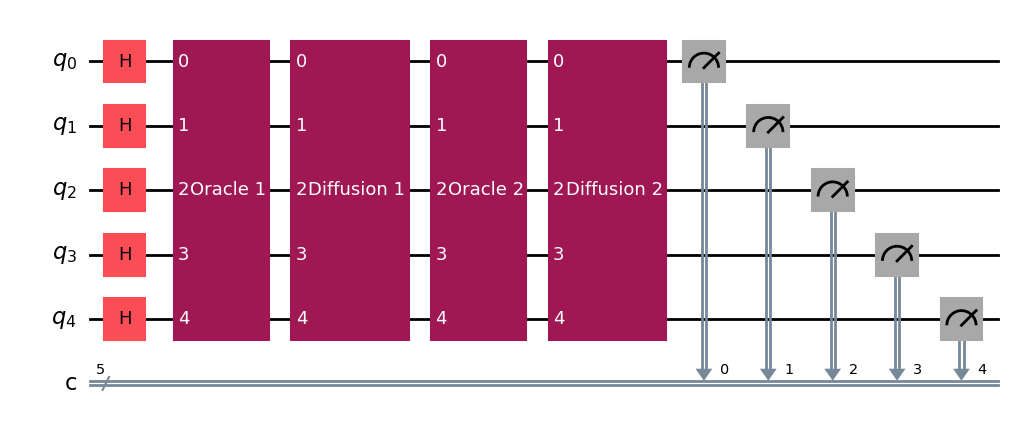

In [61]:
qc.draw('mpl', plot_barriers=False)

In [50]:
# Cenário 2
n = 2

qc, iterations = create_grover_circuit(['1' * n])

counts, duration = execute(qc, 1)

print(f'iterations={iterations} Duration:{format(duration)} Counts={counts}')
print(f'Linear search duration:{format(linear_search(n))}')

iterations=1 Duration:0h 0m 0s 49ms 96900ns Counts={'11': 1}
Linear search duration:0h 0m 0s 0ms 6100ns


In [ ]:
# Cenário 3
print('qubits;iterations;duration;time;counts')
for i in range(2, 33):
    qc, iterations = create_grover_circuit(['1' * i])

    counts, duration = execute(qc, 1024)
    print(f'{i};{iterations};{duration};{format(duration)};{counts}')

qubits;iterations;duration;counts
2;1;40675700;0h 0m 0s 40ms 675700ns;{'11': 1024}
3;2;59801100;0h 0m 0s 59ms 801100ns;{'111': 976, '001': 7, '011': 10, '101': 7, '110': 7, '000': 8, '010': 7, '100': 2}
4;3;38333700;0h 0m 0s 38ms 333700ns;{'0110': 4, '1111': 980, '0001': 6, '1110': 6, '0101': 4, '0011': 4, '1011': 2, '0111': 1, '0000': 3, '1000': 2, '1010': 2, '1101': 2, '0010': 2, '1001': 1, '0100': 4, '1100': 1}
5;4;38114200;0h 0m 0s 38ms 114200ns;{'11111': 1022, '00011': 1, '01000': 1}
6;6;20305400;0h 0m 0s 20ms 305400ns;{'111111': 1021, '010110': 1, '111110': 1, '000000': 1}
7;8;24624400;0h 0m 0s 24ms 624400ns;{'1111111': 1021, '1111110': 1, '1110111': 1, '0100001': 1}
8;12;30887700;0h 0m 0s 30ms 887700ns;{'11111111': 1024}
9;17;39630800;0h 0m 0s 39ms 630800ns;{'111111111': 1023, '110011100': 1}
10;25;65263800;0h 0m 0s 65ms 263800ns;{'1111111111': 1024}
11;35;94065800;0h 0m 0s 94ms 65800ns;{'11111111111': 1024}
12;50;126336600;0h 0m 0s 126ms 336600ns;{'111111111111': 1024}
13;71;16

In [96]:
# Cenário 4
print('qubits;iterations;duration;time;counts')
qc, iterations = create_grover_circuit(['00011', '00111', '01011']) # 3, 7, 11

counts, duration = execute(qc, 1024)

print(f'{5};{iterations};{duration};{format(duration)};{counts}')

qubits;iterations;duration;time;counts
5;2;21001200;0h 0m 0s 21ms 1200ns;{'00111': 334, '00011': 322, '01011': 368}


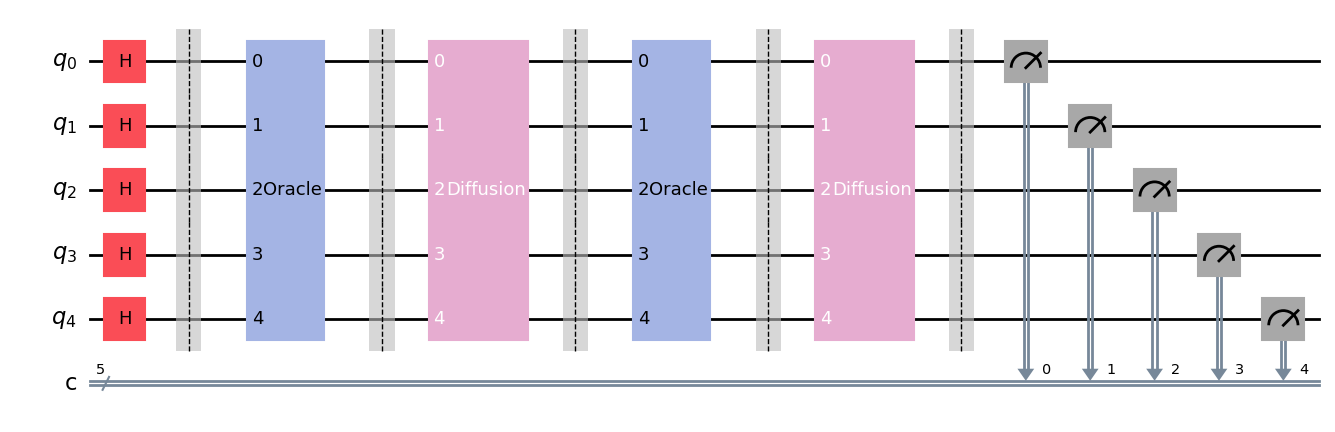

In [99]:
#qc.decompose(gates_to_decompose=['Oracle 1']).draw('mpl')
grover_style = {
    "displaycolor": {
        "Oracle": ("#A4B4E4", "#000000"), # Dourado/Amarelo
        "Diffusion": ("#E6ACD0", "#FFFFFF"), # Roxo Médio
    },
    "gatefacecolor": "#64B5F6", # Azul para portas padrão (H, X, etc)
    "barrierfacecolor": "#BDBDBD" # Cinza para barreiras
}
qc.draw(output='mpl', style=grover_style)